# Imports

In [397]:
import os
import sys
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

from fjsspw_solver.genetic_algorithm import MethodParams

# sys.path.append(str(Path(__file__).parent.parent / 'src'))

from pathlib import Path

from fjsspw_solver import GeneticAlgorithm, Individual, Encoding, GAParams
from fjsspw_solver.plotting import plot_fjsspw_gantt_on_ax, plot_learning_progress, plot_learning_progress_on_ax, PlottingParams, plot_multiple_instance_runs
from fjsspw_solver.utils import get_next_filename

from util.benchmark_parser import WorkerBenchmarkParser
import util.evaluation as evaluation

from constants import *

from pprint import pprint
from time import perf_counter

from tqdm import tqdm
from typing import List

instances_root = Path("../../instances/fjssp-w/")
output_root = Path("../../out/logs/uncertainty-factor2")

# Helpers

In [398]:
def get_instance_files(output_root, instance, run, verbose):
    if run >= 0:
        instance_log = output_root / instance / f"run_{run}"
    else:
        instance_log = output_root / instance
    config_file = instance_log / "config.cfg"
    log_file = instance_log / "evolution.log"
    out_file = instance_log / "best.out"
    
    if verbose:
        print(output_root)
        print(log_file)
        print(out_file)
    
    return instance_log, config_file, log_file, out_file

def get_encoding(instance, instances_root, verbose):
    parser = WorkerBenchmarkParser()
    encoding_py = parser.parse_benchmark(str(instances_root / f"{instance}.fjs"))

    encoding = Encoding(encoding_py.durations().tolist(), encoding_py.job_sequence())

    if verbose:
        print("-" * 20)
        print("Encoding info")
        print("n_operations:", encoding.n_operations())
        print("n_machines:", encoding.n_machines())
        print("n_workers:", encoding.n_workers())
        print("n_jobs:", encoding.n_jobs())
        print("-" * 20)

        print(encoding.get_job_sequence())
    
    return encoding, encoding_py

def plot_gantt_on_ax(ax, out_file, encoding, instance, fontsize=12, show_legend=True):
    with open(out_file, mode='r') as f:
        line = f.readline().split(' ')
        fitness, evals = line[0], line[1]
        fitness, evals = float(fitness), float(evals)
        sequence = [int(x) for x in f.readline().split(',')]
        machines = [int(x) for x in f.readline().split(',')]
        workers = [int(x) for x in f.readline().split(',')]
        start_times = [float(x) for x in f.readline().split(',')]
        end_times = [float(x) for x in f.readline().split(',')]
    plot_fjsspw_gantt_on_ax(ax, sequence, machines, workers, start_times, end_times, encoding, instance, fitness, fontsize=fontsize, show_legend=show_legend)

def visualize(instance: str, instances_root: Path = instances_root, output_root: Path = output_root, verbose: bool = False, run: int = 0):
    instance_log, config_file, log_file, out_file = get_instance_files(output_root, instance, run, verbose)
    if not instance_log.is_dir() or not log_file.is_file() or not out_file.is_file():
        return
    
    encoding, _ = get_encoding(instance, instances_root, verbose)
    
    plotting_params = PlottingParams(
        instance_name = "".join(instance.lower().split("_")[1:-1]),
        bounds_file = "../../instances/InstanceData/FJSSP-W/new_best_known.csv",
        selection_type = "Tournament",
        crossover_type = "MOX",
        mutation_type = "Mixed"
    )
    
    fig, axes = plt.subplots(3, 1, figsize=(24, 24))
    plot_learning_progress_on_ax(axes[0], log_file, plotting_params)
    plot_learning_progress_on_ax(axes[1], log_file, plotting_params, zoom=True)
    # plot_gantt(out_file, fontsize=8, show_legend=False)
    plot_gantt_on_ax(axes[2], out_file, encoding, instance, show_legend=False)
    plt.tight_layout()
    plt.show()

def visualize_weights(instance: str):
    df = pd.read_csv(output_root / instance / "run_0" / "evolution.log")
    df = df.drop(columns=["worst", "avg", "best", "best_so_far", "evals"])
    df.plot(x="generation", grid=True, figsize=(12, 8))


def get_deterministic_fitness(individual_file: Path, encoding_py):
    with open(individual_file, mode='r', encoding='utf-8') as handle:
        handle.readline()
        sequence = [int(x) for x in handle.readline().split(',')]
        machines = [int(x) for x in handle.readline().split(',')]
        workers = [int(x) for x in handle.readline().split(',')]
        start_times, machines, workers = evaluation.translate(sequence, machines, workers, encoding_py.durations())
        c = evaluation.makespan(start_times, machines, workers, encoding_py.durations())
    return c, f"Deterministic={c}"
        

def visualize_compare(instance: str, instances_root: Path = instances_root, output_roots: List[Path] = [output_root], verbose: bool = False, run: int = 0):
    instances_files = []
    for output in output_roots:
        instances_files.append(get_instance_files(output, instance, run, verbose))
        
    cnt = 0
    
    plotting_files = []
    for instance_log, config_file, log_file, out_file in instances_files:
        if not instance_log.is_dir() or not log_file.is_file() or not out_file.is_file():
            continue
        cnt += 1
        plotting_files.append((log_file, config_file, out_file))
    
    fig, axes = plt.subplots(cnt, 1, figsize=(24, 24))
    for i, (log_file, config_file, out_file) in enumerate(plotting_files):
        plotting_params = PlottingParams(
            instance_name = "".join(instance.lower().split("_")[1:-1]),
            bounds_file = "../../instances/InstanceData/FJSSP-W/new_best_known.csv",
            selection_type = "Tournament",
            crossover_type = "MOX",
            mutation_type = "Mixed"
        )
        with open(config_file, mode='r', encoding='utf-8') as config:
            deterministic = None
            if 'UNCERTAINTY_PARAMS_PATH' in config.read():
                _, encoding = get_encoding(instance, instances_root, verbose)
                deterministic = get_deterministic_fitness(out_file, encoding)
        plot_learning_progress_on_ax(axes[i], log_file, plotting_params, zoom=True, deterministic=deterministic)        
    
    plt.tight_layout()
    plt.show()

# Instance single run visualisation

## Small

In [399]:
visualize("0_BehnkeGeiger_42_workers")

In [400]:
visualize("2a_Hurink_sdata_1_workers")

In [401]:
visualize("2b_Hurink_edata_1_workers")

In [402]:
visualize("2b_Hurink_edata_6_workers")

In [403]:
visualize("2c_Hurink_rdata_50_workers")

In [404]:
visualize("2d_Hurink_vdata_5_workers")

In [405]:
visualize("5_Kacem_3_workers")

In [406]:
visualize("5_Kacem_4_workers")

In [407]:
visualize("6_Fattahi_14_workers")

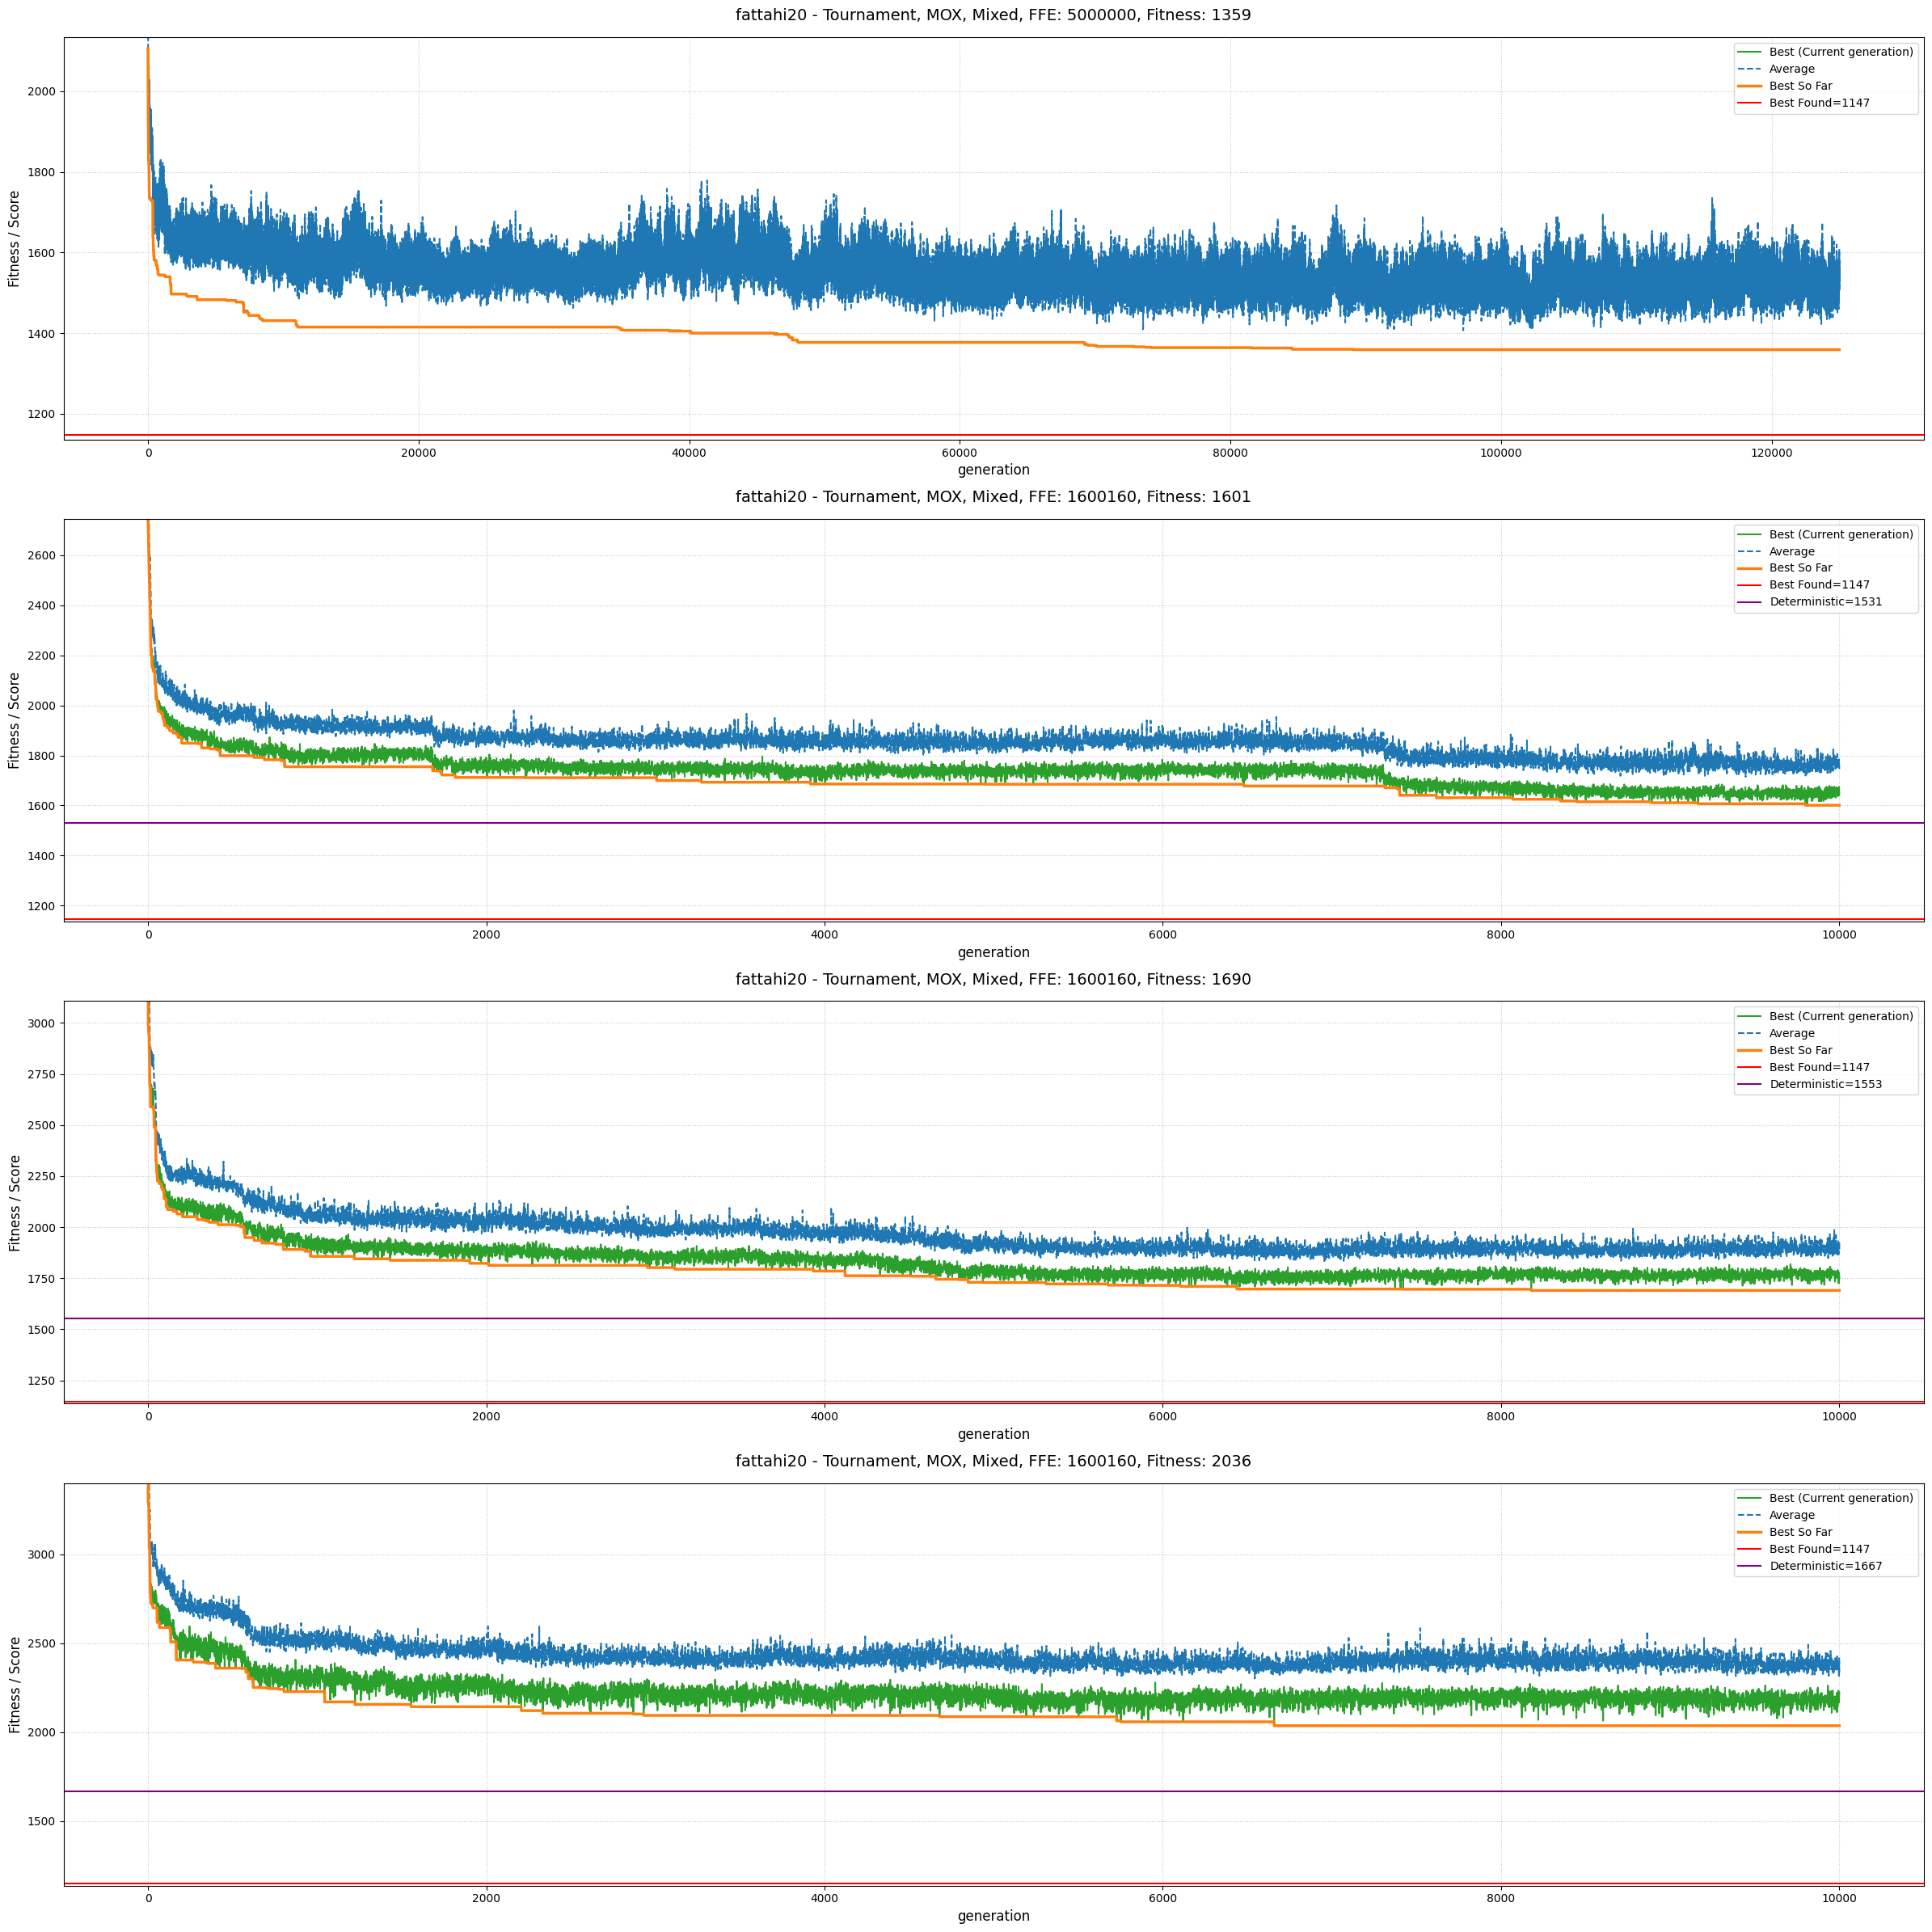

In [408]:
# visualize("6_Fattahi_20_workers", run=3, output_root=Path("../../out/logs/uncertainty-factor10"))
out_root = Path("../../out/logs/")
visualize_compare("6_Fattahi_20_workers", run=-1, output_roots=[out_root / "deterministic",out_root / "uncertainty-factor10", out_root / "uncertainty-factor5", out_root / "uncertainty-factor2"])

## Medium

In [409]:
visualize("0_BehnkeGeiger_46_workers")

In [410]:
visualize("1_Brandimarte_7_workers")

In [411]:
visualize("2a_Hurink_sdata_18_workers")

In [412]:
visualize("2a_Hurink_sdata_54_workers")

In [413]:
visualize("2a_Hurink_sdata_61_workers")

In [414]:
visualize("2a_Hurink_sdata_63_workers")

In [415]:
visualize("2d_Hurink_vdata_18_workers")

## Large

In [416]:
visualize("1_Brandimarte_12_workers")

In [417]:
visualize("1_Brandimarte_14_workers")

In [418]:
visualize("2a_Hurink_sdata_40_workers")

In [419]:
visualize("2c_Hurink_rdata_28_workers")

In [420]:
visualize("2d_Hurink_vdata_30_workers")

In [421]:
visualize("3_DPpaulli_1_workers")

In [422]:
visualize("3_DPpaulli_9_workers")

In [423]:
visualize("4_ChambersBarnes_10_workers")

## Very large

In [424]:
visualize("0_BehnkeGeiger_60_workers")

In [425]:
visualize("2a_Hurink_sdata_38_workers")

In [426]:
visualize("2c_Hurink_rdata_38_workers")

In [427]:
visualize("3_DPpaulli_15_workers")

In [428]:
visualize("3_DPpaulli_18_workers")

# Joined results

In [429]:
def fix_results(output_root: Path):
    dfs = []
    for instance in output_root.iterdir():
        if instance.is_file():
            continue
        i_df = pd.read_csv(instance / "results.csv", sep=";")
        dfs.append(i_df)
        i_df[['StartTimes', 'WorkerAssignments']] = i_df[['WorkerAssignments', 'StartTimes']]
        i_df[['MachineAssignments', 'WorkerAssignments']] = i_df[['WorkerAssignments', 'MachineAssignments']]
        i_df.to_csv(instance / "results_fixed.csv", sep=";", index=False)
    df = pd.concat(dfs)
    df.to_csv(output_root / "results.csv", sep=";", index=False)
# fix_results(output_root)

In [430]:
def join_results(output_root: Path):
    if (output_root / "results.csv").is_file():
        return pd.read_csv(output_root / "results.csv", sep=";")
    dfs = []
    for instance in output_root.iterdir():
        dfs.append(pd.read_csv(instance / "results.csv", sep=";"))
    return pd.concat(dfs)

In [431]:
results = join_results(output_root)

In [432]:
results

,Instance,Fitness,FunctionEvaluations,MachineAssignments,WorkerAssignments,StartTimes
0,6_Fattahi_20_workers,2036,1065440,"[0,3,4,6,0,1,5,7,0,3,5,7,0,2,3,5,0,6,4,5,1,3,5...","[3,1,2,10,11,0,3,2,11,6,3,11,10,10,1,9,2,3,8,1...","[528,927,1521,1763,0,233,336,443,388,753,927,1..."


In [433]:
lower_bound_file = Path("../../instances/InstanceData/FJSSP-W/new_best_known.csv")
lower_bounds = pd.read_csv(lower_bound_file, sep=";")

In [434]:
lower_bounds

,Instance,UB,LB
0,behnkegeiger10,125.0,75.0
1,behnkegeiger11,228.0,74.0
2,behnkegeiger12,223.0,71.0
3,behnkegeiger13,234.0,76.0
4,behnkegeiger14,238.0,82.0
...,...,...,...
397,hurinkvdata9,763.0,380.0
398,kacem1,11.0,11.0
399,kacem2,10.0,10.0
400,kacem3,7.0,7.0


In [435]:
groupped_results = results.groupby("Instance")

In [436]:
original_stats = groupped_results['Fitness'].describe().reset_index().drop(columns=['count'])

In [437]:
def instance_name(full_name):
    return "".join(full_name.lower().split("_")[1:-1])

In [438]:
stats = (
    original_stats.assign(temp_key=original_stats['Instance'].apply(instance_name))
    .merge(
        lower_bounds, 
        left_on='temp_key', 
        right_on='Instance', # or right_index=True,
        suffixes=['', '_copy']
    )
    .drop(columns=['temp_key', 'Instance_copy', 'LB'])
)

col_lb = stats.pop('UB')
col_min = stats.pop('min')
stats.insert(1, 'Optimal (or best found)', col_lb)
stats.insert(2, 'Our best', col_min)

import numpy as np

# If best result is 0, we'll just call the gap 0 (or whatever logic you prefer)
col_gap = np.where(
    stats['Optimal (or best found)'] != 0, 
    np.round(((stats['Our best'] - stats['Optimal (or best found)']) / stats['Optimal (or best found)']) * 100, 2), 
    0
)
stats.insert(3, 'Gap %', col_gap)

In [439]:
stats

,Instance,Optimal (or best found),Our best,Gap %,mean,std,25%,50%,75%,max
0,6_Fattahi_20_workers,1147.0,2036.0,77.51,2036.0,NaN,2036.0,2036.0,2036.0,2036.0


In [440]:
problematic = stats[stats['UB'] > stats['best']]

KeyError: 'UB'

In [ ]:
print(problematic.shape)
problematic

(1, 10)


,Instance,UB,best,Gap %,mean,std,25%,50%,75%,max
12,2a_Hurink_sdata_63_workers,386.0,383.0,-0.78,400.6,12.456145,393.25,399.0,409.75,423.0


# Sanity check fitness

In [ ]:
import util.evaluation as evaluation
import ast

def handle_instance_sanity_check(row):
    instance = row['Instance']
    
    # print(instance)
    parser = WorkerBenchmarkParser()
    encoding = parser.parse_benchmark(str(instances_root / f"{instance}.fjs"))

    start_times = ast.literal_eval(row['StartTimes'])
    machines = ast.literal_eval(row['MachineAssignments'])
    workers = ast.literal_eval(row['WorkerAssignments'])
    
    # print(start_times, machines, workers, sep='\n')
    # print(type(start_times), type(machines), type(workers), sep='\n')
    # durations = encoding.durations()
    # end_times = []
    # for i in range(len(start_times)):
        # print(f"operation_idx={i}, machine={machines[i]}, worker={workers[i]}", end="")
        # print(f", duration={durations[i][machines[i]][workers[i]]}")
        # end_times.append(start_times[i] + durations[i][machines[i]][workers[i]])
    
    fitness = evaluation.makespan(start_times, machines, workers, encoding.durations())
    
    return fitness

def sanity_check(df):
    df['sanity_fitness'] = df.apply(handle_instance_sanity_check, axis=1)
sanity_check(results)

In [ ]:
results.loc[:,['Fitness', 'sanity_fitness']]

,Fitness,sanity_fitness
0,104,104
1,97,97
2,101,101
3,103,103
4,102,102
...,...,...
295,1438,1438
296,1378,1378
297,1380,1380
298,1307,1307


In [ ]:
print(f"Difference between actual fitness and the sanity checked fitness:", sum([row['Fitness'] - row['sanity_fitness'] for _, row in results.iterrows()]))

Difference between actual fitness and the sanity checked fitness: 0
